随机森林


训练集 R² (对数尺度): 0.5770
验证集 R² (对数尺度): 0.4036
测试集 R² (对数尺度): 0.3710
测试集 R² (原始票房): 0.5270


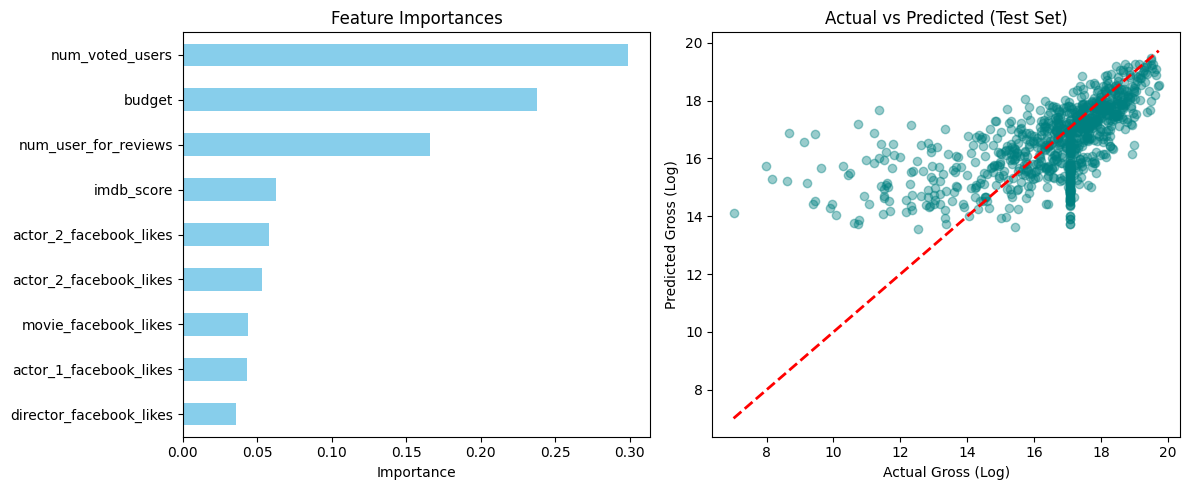

['random_forest_model.pkl']

In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# ==================== 1. 加载与清洗 ====================
df = pd.read_csv('D:/bishe_zoujun/Flask/data_all/movies_all_cleaned.csv')

features = [
    'budget', 'director_facebook_likes', 'actor_1_facebook_likes',
    'actor_2_facebook_likes','actor_2_facebook_likes','movie_facebook_likes',
    'num_voted_users', 'num_user_for_reviews', 'imdb_score'
]
target = 'gross'

# 剔除特征或目标值缺失的行
data = df.dropna(subset=[target] + features)

X = data[features]
y = data[target]

# ==================== 2. 三阶段数据集划分 ====================
# 先分出测试集 (20%)，再从剩余中分出验证集 (约 20% of original -> 25% of remaining)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# ==================== 3. 对数转换目标变量 ====================
# 在对数空间训练，提升对低票房的预测能力
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

# ==================== 4. 模型训练 ====================
# 平衡性能与过拟合
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train_log)

# ==================== 5. 预测与尺度转换 ====================
def get_metrics(model, X, y_true, y_true_log_val):
    y_pred_log = model.predict(X)  # 模型直接输出对数预测值
    y_pred = np.expm1(y_pred_log)  # 转换回原始尺度
    
    # 原始尺度 R2
    r2_orig = r2_score(y_true, y_pred)
    
    # 对数尺度 R2
    r2_log = r2_score(y_true_log_val, y_pred_log)
    
    return r2_orig, r2_log, y_true_log_val, y_pred_log

# 计算各集合指标
train_r2_orig, train_r2_log, _, _ = get_metrics(model, X_train, y_train, y_train_log)
val_r2_orig, val_r2_log, _, _ = get_metrics(model, X_val, y_val, y_val_log)
test_r2_orig, test_r2_log, y_test_log_true, y_pred_log = get_metrics(model, X_test, y_test, y_test_log)

# ==================== 5. 格式化评估输出 ====================
print("\n" + "="*30)
print(f"训练集 R² (对数尺度): {train_r2_log:.4f}")
print(f"验证集 R² (对数尺度): {val_r2_log:.4f}")
print(f"测试集 R² (对数尺度): {test_r2_log:.4f}")
print(f"测试集 R² (原始票房): {test_r2_orig:.4f}")
print("="*30)

# ==================== 6. 可视化模块 ====================
plt.figure(figsize=(12, 5))

# 图1：特征重要性 (参考 notebook 风格)
plt.subplot(1, 2, 1)
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
importances.plot(kind='barh', color='skyblue')
plt.title('Feature Importances')
plt.xlabel('Importance')

# 图2：测试集预测值 vs 真实值 (对数尺度)
plt.subplot(1, 2, 2)
plt.scatter(y_test_log, y_pred_log, alpha=0.4, color='teal')
plt.plot([y_test_log.min(), y_test_log.max()], [y_test_log.min(), y_test_log.max()], 'r--', lw=2)
plt.xlabel('Actual Gross (Log)')
plt.ylabel('Predicted Gross (Log)')
plt.title('Actual vs Predicted (Test Set)')

plt.tight_layout()
plt.show()

joblib.dump(model, 'random_forest_model.pkl')